In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy

In [2]:
t_obs = 1*30*24*60*60.0
nu_range=np.arange(-277.76*10**-6,277.76*10**-6,1/t_obs)
nu_range_custom= np.linspace(-277.76*10**-6,277.76*10**-6,100000)
# np.sinc(3.14*nu_range*t_obs)
# 1/t_obs
nu_range.shape
# 3.14*nu_range*t_obs

(1440,)

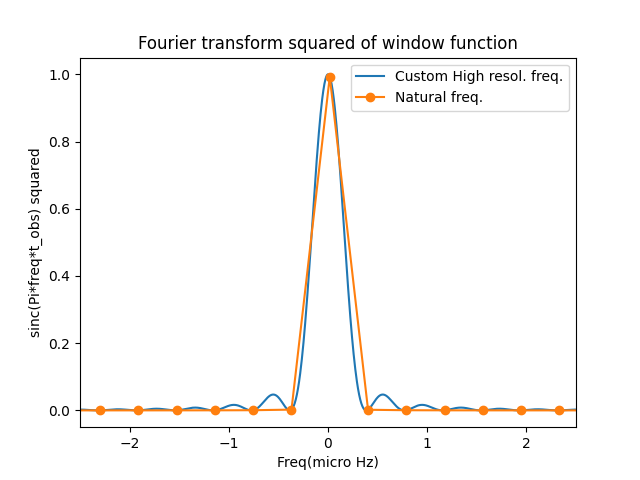

In [3]:
%matplotlib widget
plt.figure()
plt.plot(nu_range_custom*10**6,np.sinc(nu_range_custom*t_obs)**2,label = 'Custom High resol. freq.')
plt.plot(nu_range*10**6,np.sinc(nu_range*t_obs)**2,'-o',label = 'Natural freq.')
plt.ylabel('sinc(Pi*freq*t_obs) squared')
plt.xlabel('Freq(micro Hz)')
plt.title('Fourier transform squared of window function')
plt.legend()
plt.xlim(-2.5,2.5)
plt.show()

In [4]:
def lpeak(x,x0,h,fwhm):
    return h*(fwhm/2)**2/((x-x0)**2+(fwhm/2)**2)


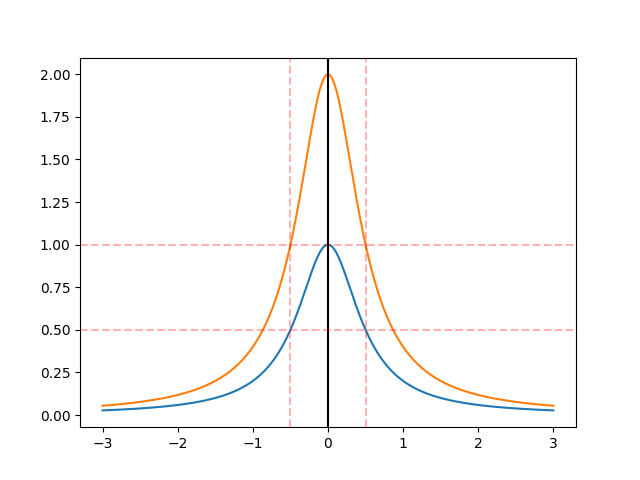

In [5]:
prange = np.linspace(-3,3,400)
plt.figure()
plt.plot(prange,lpeak(prange,0,1,1))
plt.plot(prange,lpeak(prange,0,2,1))
plt.axvline(0,color='k')
plt.axvline(-1/2,color='r',linestyle='--',alpha=0.3)
plt.axvline(1/2,color='r',linestyle='--',alpha=0.3)
plt.axhline(1,color='r',linestyle='--',alpha=0.3)
plt.axhline(1/2,color='r',linestyle='--',alpha=0.3)
plt.show()

In [6]:
def exp_decay(t,a=1,nu0=100*1e-6,tau=np.inf):
    return a*np.exp(-t/tau)*np.sin(2*np.pi*nu0*t)

In [7]:
print(exp_decay(np.array([0,0.2,0.202]),tau=100))
#print(1*np.exp(-0.2/10))

[0.         0.00012541 0.00012666]


In [8]:
1e6/np.pi/0.1/(60*60*24),

(36.841422012012806,)

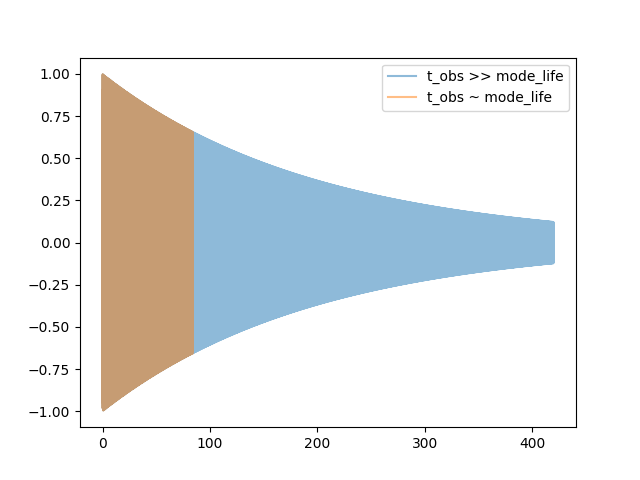

In [525]:
t_obs2 = 84*24*60*60
t_obs = 5*t_obs2    #365*24*60*60
del_obs = 30*60
t_samp = np.arange(0,t_obs+del_obs,del_obs)
t_samp2 = np.arange(0,t_obs2+del_obs,del_obs)

life_samp = 200*(24*60*60)
signal = exp_decay(t_samp,tau=life_samp)
signal2 = exp_decay(t_samp2,tau=life_samp)
plt.figure()
plt.plot(t_samp/(60*60*24),signal,alpha=0.5,label='t_obs >> mode_life')
plt.plot(t_samp2/(60*60*24),signal2,alpha=0.5,label='t_obs ~ mode_life')
plt.legend()
plt.show()

In [526]:
t_samp

array([       0,     1800,     3600, ..., 36284400, 36286200, 36288000])

In [527]:
signal_fft = scipy.fft.fft(signal)
signal_freq = scipy.fft.fftfreq(len(signal),t_samp[-1]/t_samp.shape[0])
signal_freq

array([ 0.00000000e+00,  2.75573192e-08,  5.51146384e-08, ...,
       -8.26719577e-08, -5.51146384e-08, -2.75573192e-08])

In [528]:
signal2_fft = scipy.fft.fft(signal2)
signal_freq2 = scipy.fft.fftfreq(len(signal2),t_samp2[-1]/t_samp2.shape[0])

In [529]:
1e6*signal_freq2[(signal_freq2>98/1e6)&(signal_freq2<102/1e6)]

array([ 98.10405644,  98.24184303,  98.37962963,  98.51741623,
        98.65520282,  98.79298942,  98.93077601,  99.06856261,
        99.20634921,  99.3441358 ,  99.4819224 ,  99.61970899,
        99.75749559,  99.89528219, 100.03306878, 100.17085538,
       100.30864198, 100.44642857, 100.58421517, 100.72200176,
       100.85978836, 100.99757496, 101.13536155, 101.27314815,
       101.41093474, 101.54872134, 101.68650794, 101.82429453,
       101.96208113])

In [530]:
psd = (np.abs(signal_fft)**2)/len(signal)
psd2 = (np.abs(signal2_fft)**2)/len(signal2)

norm_psd = np.sum(np.abs(signal)**2)/(np.sum(psd))
norm_psd2 = np.sum(np.abs(signal2)**2)/(np.sum(psd2))
norm_psd,norm_psd2

(1.0, 1.0)

In [531]:
np.sum(np.abs(signal)**2),np.sum(psd),np.sum(np.abs(signal2)**2),np.sum(psd2)

(2364.018410710014, 2364.018410710014, 1364.1160727765018, 1364.1160727765018)

In [532]:
signal_low_res = signal[::5]
signal_low_res_fft = scipy.fft.fft(signal_low_res)
signal_low_res_freq = scipy.fft.fftfreq(len(signal_low_res),t_samp[::5][-1]/t_samp[::5].shape[0])
psd_low_res = (np.abs(signal_low_res_fft)**2)/len(signal_low_res)
norm_psd_low_res = np.sum(np.abs(signal_low_res)**2)/(np.sum(psd_low_res))

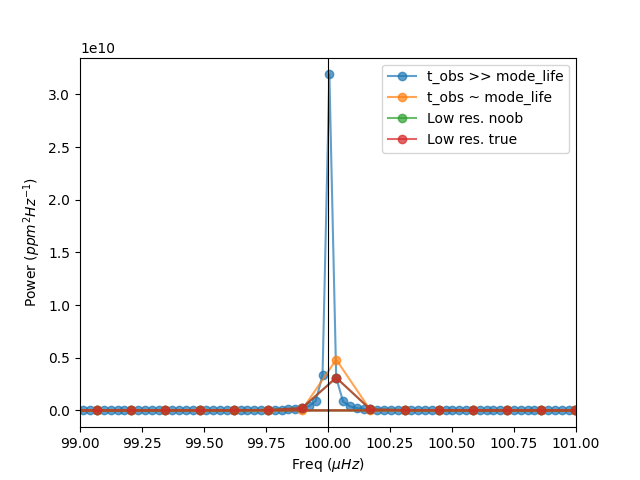

In [533]:
plt.figure()
plt.plot(signal_freq*1e6,norm_psd*psd*t_obs,'o-',label='t_obs >> mode_life',alpha=0.7)
plt.plot(signal_freq2*1e6,norm_psd2*psd2*t_obs2,'o-',label='t_obs ~ mode_life',alpha=0.7)
plt.plot(signal_freq[::5]*1e6,norm_psd*psd[::5]*t_obs,'o-',label='Low res. noob',alpha=0.7)
plt.plot(signal_freq[::5]*1e6,norm_psd_low_res*psd[::5]*t_obs,'o-',label='Low res. true',alpha=0.7)
plt.axvline(100,linewidth=0.8,color='black')
plt.xlabel(r'Freq ($\mu Hz$)')
plt.ylabel(r'Power ($ppm^{2}Hz^{-1}$)')
plt.xlim(99,101)
# plt.xlim(0,)
plt.legend()
# plt.tight_layout()
plt.show()

In [457]:
sinc_part = np.sinc(signal_freq2*t_obs2)**2
sinc_part

array([1.00000000e+00, 3.25224089e-32, 3.25224089e-32, ...,
       1.51957436e-33, 3.25224089e-32, 3.25224089e-32])

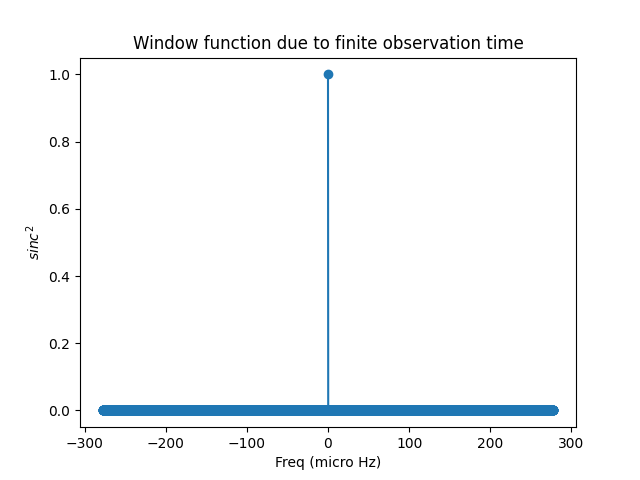

In [458]:
plt.figure()
plt.plot(signal_freq2*1e6,sinc_part,'o-')
# plt.xlim(-1,1)
plt.title('Window function due to finite observation time')
plt.xlabel('Freq (micro Hz)')
plt.ylabel(r'$sinc^2$')
# plt.legend()
plt.show()

In [459]:
psd.shape,psd2.shape,sinc_part.shape

((21121,), (4225,), (4225,))

In [460]:
conv_signal = scipy.signal.convolve(psd,sinc_part,'same')
conv_signal.shape

(21121,)

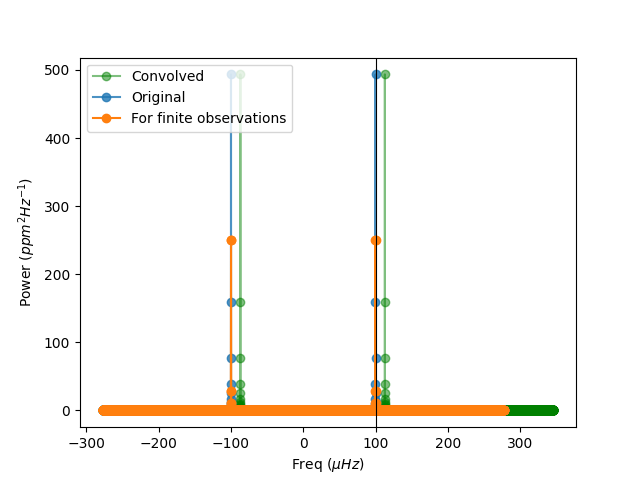

In [461]:
plt.figure()
plt.plot(signal_freq*1e6+68.5,conv_signal,'o-',label='Convolved',color='green',alpha=0.5)
#We added the offset to compensate for the shift introduced due to convolution
plt.plot(signal_freq*1e6,psd,'o-',label='Original',alpha=0.8)
plt.plot(signal_freq2*1e6,psd2,'o-',label='For finite observations',alpha=1)
plt.axvline(100,linewidth=0.8,color='black')
plt.xlabel(r'Freq ($\mu Hz$)')
plt.ylabel(r'Power ($ppm^{2}Hz^{-1}$)')
# plt.xlim(99,101)
plt.legend()
plt.show()

# Possible solution : Sample every 10th point from a PSD with 10 times the resolution

plt.figure()
plt.plot